In [7]:
# apri una cartella DICOM e apri il file DICOM
# per visualizzarlo con pydicom e matplotlib
import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
from skimage import measure

def carica_volume_dicom(cartella):
    files = [f for f in os.listdir(cartella) if f.lower().endswith('.dcm')]
    paths = [os.path.join(cartella, f) for f in files]
    datasets = [pydicom.dcmread(p) for p in paths]
    try:
        datasets.sort(key=lambda ds: float(ds.ImagePositionPatient[2]))
    except Exception:
        datasets.sort(key=lambda ds: int(ds.InstanceNumber))
    # Conversione in HU
    slices_hu = []
    for ds in datasets:
        img = ds.pixel_array.astype(np.float32)
        slope = float(ds.RescaleSlope)
        intercept = float(ds.RescaleIntercept)
        img_hu = img * slope + intercept
        slices_hu.append(img_hu)
    volume_hu = np.stack(slices_hu, axis=0)
    return volume_hu

def mostra_fette(volume, num_fette=5):
    step = max(1, volume.shape[0] // num_fette)
    for i in range(0, volume.shape[0], step):
        plt.imshow(volume[i], cmap='bone')
        plt.title(f"Slice {i}")
        plt.axis('off')
        plt.show()
        if i // step + 1 >= num_fette:
            break



In [8]:
# crea una ROI cilindrica di raggio 10 pixel e spessore 5 pixel centrata in [50,50, 38]
def crea_roi_cilindrica(volume, centro, raggio, spessore):
    """
    Crea una maschera cilindrica in un volume 3D.
    centro: [z, y, x] (int)
    raggio: raggio del cilindro (int)
    spessore: numero di slice lungo z (int, deve essere dispari per simmetria)
    """
    num_z, num_y, num_x = volume.shape
    zz, yy, xx = np.ogrid[:num_z, :num_y, :num_x]
    mask = (
        (xx - centro[2])**2 + (yy - centro[1])**2 <= raggio**2
    ) & (
        np.abs(zz - centro[0]) <= spessore // 2
    )
    return mask

# plotta il bordo della ROI sopra la fetta centrale 
def mostra_roi_sovrapposta(volume, mask, z):
    plt.imshow(volume[z], cmap='bone')
    # Trova i contorni della ROI
    contours = measure.find_contours(mask[z], 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=2)
    plt.title(f"ROI sovrapposta alla slice z={z}")
    plt.axis('off')
    plt.show()

# mostra ROI sovrapposta con zoom attorno al centro della ROI



    

# plotta solo la ROI
def mostra_solo_roi(volume, mask, z):
    plt.imshow(volume[z] * mask[z], cmap='gray')
    plt.title(f"ROI cilindrica - slice z={z}")
    plt.axis('off')
    plt.show()

def mostra_bordo_proiezione_laterale(volume, mask, num_slices=30):
    """
    Mostra solo il bordo della ROI sulla proiezione laterale (z-y),
    considerando solo num_slices slice attorno a quella centrale.
    """
    z_centro = volume.shape[0] // 2
    half = num_slices // 2
    z_start = max(0, z_centro - half)
    z_end = min(volume.shape[0], z_centro + half)

    # Proiezione massima lungo x, solo sulle slice selezionate
    proiezione_volume = np.max(volume[z_start:z_end], axis=2)
    proiezione_mask = np.max(mask[z_start:z_end], axis=2)

    plt.imshow(proiezione_volume, cmap='bone')

    # Trova i contorni della ROI proiettata
    contours = measure.find_contours(proiezione_mask, 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='blue', linewidth=2)

    plt.title(f"Bordo ROI sulla proiezione laterale (z-y), slice {z_start}:{z_end}")
    plt.axis('off')
    plt.show()

In [9]:
#Fai istogramma dei valori contenuti nella ROI
def calcola_histogram(volume, roi=None, roi_name=None):
    """
    Restituisce hist, bin_edges dell'istogramma dei valori del volume (o della ROI).
    """
    if roi is not None:
        mask = np.zeros(volume.shape, dtype=bool)
        mask[roi] = True
        data = volume[mask]
    else:
        data = volume.flatten()
    
    num_bins = int(np.sqrt(data.size))
    hist, bin_edges = np.histogram(data, bins=num_bins)

    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7)
    plt.title(f'Histogram of {roi_name}')
    plt.xlabel('Pixel Value')
    plt.ylabel('Count')
    plt.grid()
    plt.show()
    return hist, bin_edges


In [10]:
def mostra_crop_con_maschera(volume, mask, z, margin=20):
    """
    Mostra una versione croppata della slice z con la maschera sovrapposta.
    Il crop è centrato sulla maschera, con un margine opzionale.
    """
    # Trova i bounding box della maschera sulla slice z
    coords = np.argwhere(mask[z])
    if coords.size == 0:
        print("Maschera vuota nella slice selezionata.")
        return
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    # Applica margine e limiti
    y_min = max(y_min - margin, 0)
    y_max = min(y_max + margin, volume.shape[1])
    x_min = max(x_min - margin, 0)
    x_max = min(x_max + margin, volume.shape[2])

    # Croppa immagine e maschera
    img_crop = volume[z, y_min:y_max, x_min:x_max]
    mask_crop = mask[z, y_min:y_max, x_min:x_max]

    plt.imshow(img_crop, cmap='bone')
    contours = measure.find_contours(mask_crop, 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='red', linewidth=2)
    plt.title(f"Crop slice {z} con maschera sovrapposta")
    plt.colorbar()
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()


def mostra_crop_laterale_con_maschera(volume, mask, margin=10):
    """
    Mostra la proiezione laterale (z-y) croppata attorno alla maschera,
    con il bordo della maschera sovrapposto.
    """
    # Proiezione massima lungo x (z-y)
    proiezione_volume = np.max(volume, axis=2)
    proiezione_mask = np.max(mask, axis=2)

    # Trova bounding box della maschera proiettata
    coords = np.argwhere(proiezione_mask)
    if coords.size == 0:
        print("Maschera vuota nella proiezione.")
        return
    z_min, y_min = coords.min(axis=0)
    z_max, y_max = coords.max(axis=0)
    z_min = max(z_min - margin, 0)
    z_max = min(z_max + margin, volume.shape[0])
    y_min = max(y_min - margin, 0)
    y_max = min(y_max + margin, volume.shape[1])

    # Croppa proiezione e maschera
    img_crop = proiezione_volume[z_min:z_max, y_min:y_max]
    mask_crop = proiezione_mask[z_min:z_max, y_min:y_max]

    plt.imshow(img_crop, cmap='bone')
    contours = measure.find_contours(mask_crop, 0.5)
    for contour in contours:
        plt.plot(contour[:, 1], contour[:, 0], color='red', linewidth=2)
    plt.title("Crop proiezione laterale (z-y) con maschera")
    plt.xlabel('Y-axis')
    plt.ylabel('Z-axis')
    plt.colorbar()
    plt.show()

In [11]:
# Calcolare alcune metrice degli istogrammi: media, mediana, varianza, deviazione_standard, skewness, kurtosis
def calcola_metriche_istogramma(hist, bin_edges):
    """
    Calcola e restituisce le metriche dell'istogramma: media, mediana, varianza, skewness, kurtosis.
    """
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total_count = hist.sum()
    
    # Media
    mean = np.sum(hist * bin_centers) / total_count
    
    # Mediana
    cumulative_hist = np.cumsum(hist)
    median_index = np.searchsorted(cumulative_hist, total_count / 2)
    median = bin_centers[median_index]
    
    # Varianza
    variance = np.sum(hist * (bin_centers - mean)**2) / total_count

    # Deviazione standard
    std_dev = np.sqrt(variance)
    
    # Skewness
    skewness = np.sum(hist * (bin_centers - mean)**3) / (total_count * variance**1.5)
    
    # Kurtosis
    kurtosis = np.sum(hist * (bin_centers - mean)**4) / (total_count * variance**2) - 3
    
    return mean, median, variance, std_dev, skewness, kurtosis

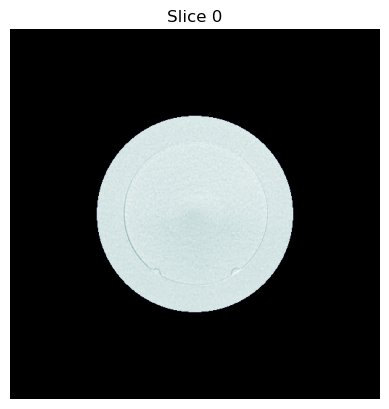

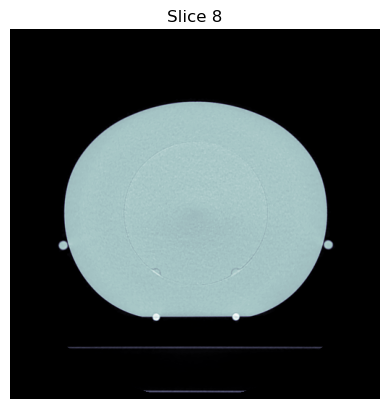

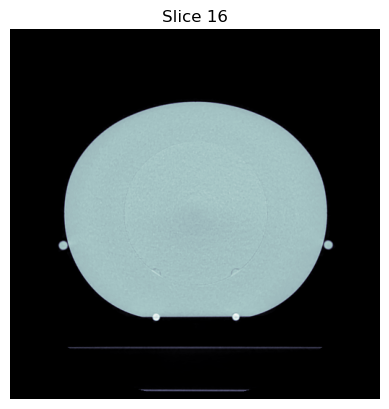

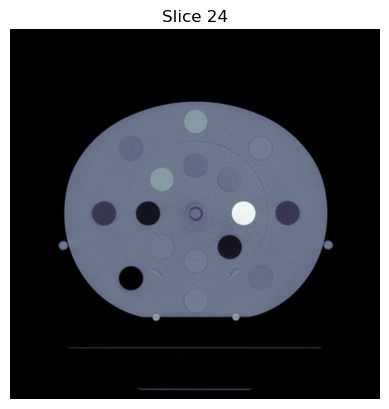

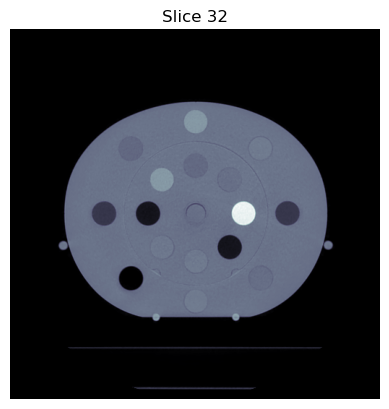

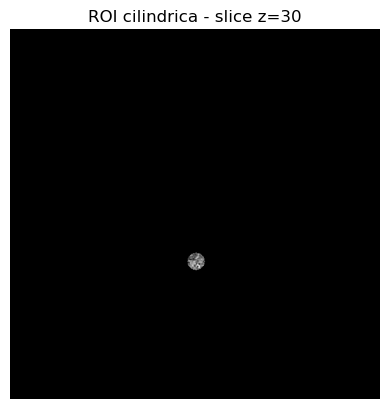

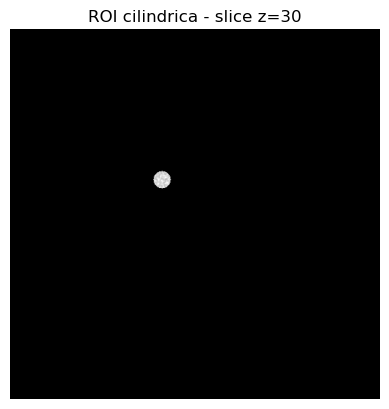

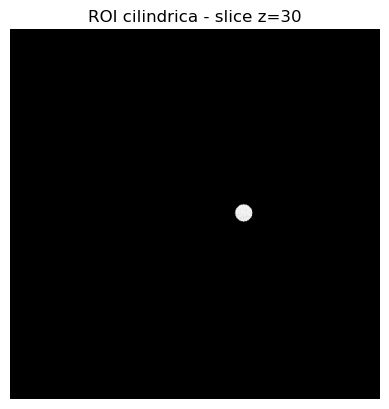

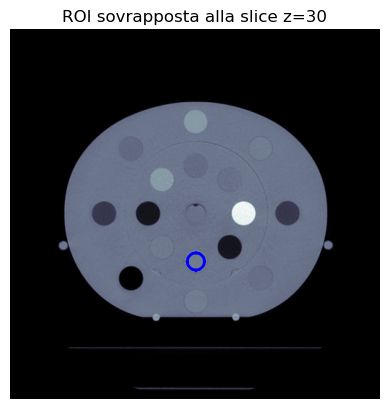

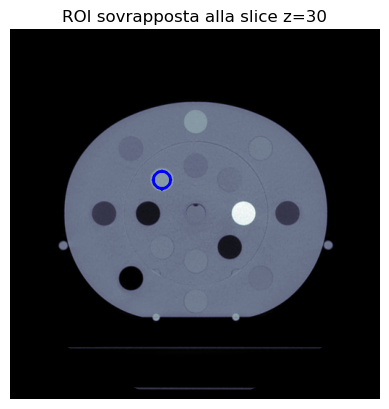

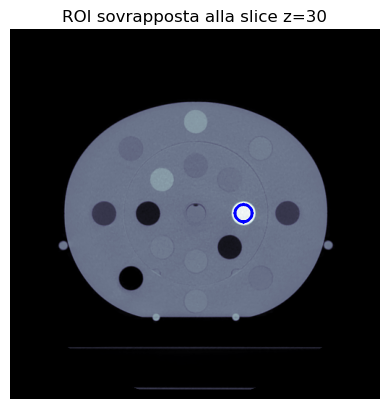

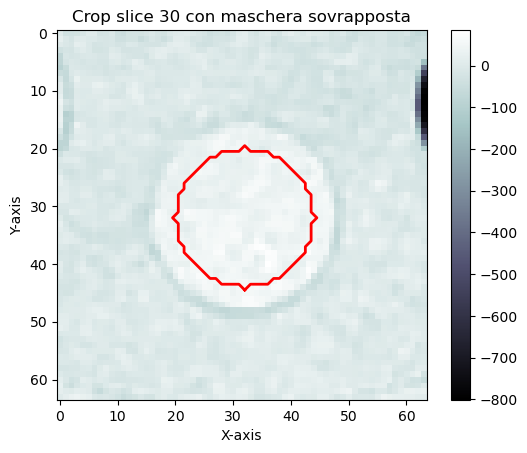

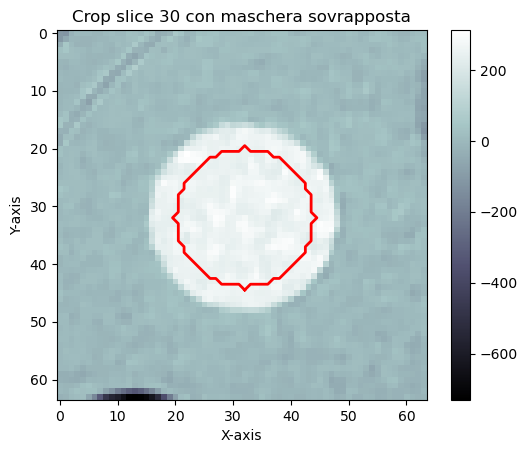

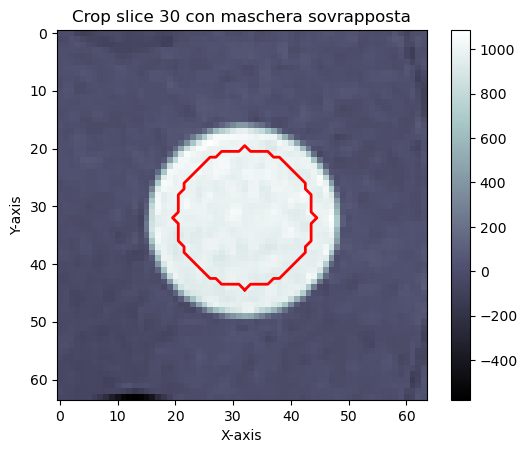

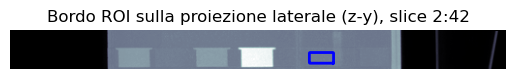

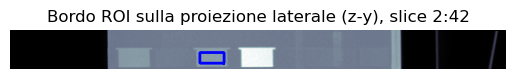

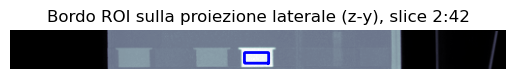

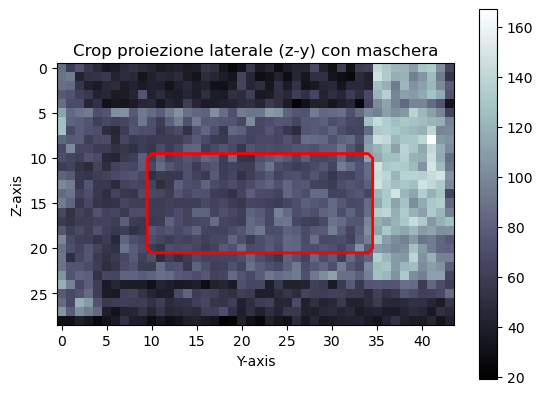

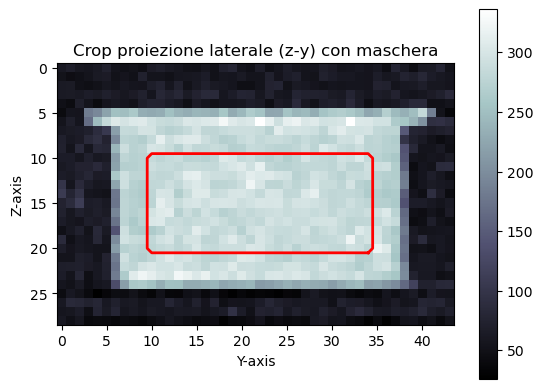

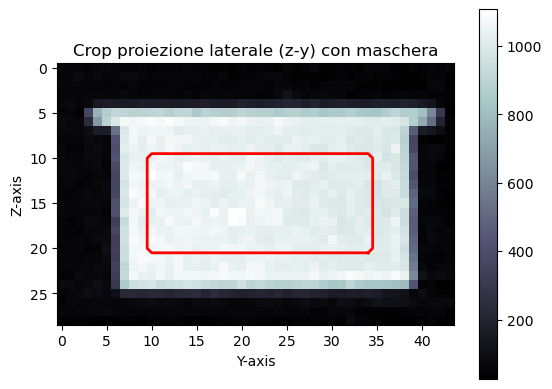

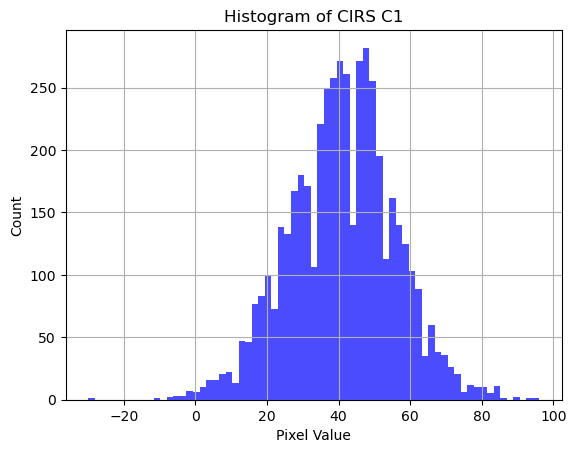

[  1   0   0   0   0   0   0   0   0   0   1   0   2   3   3   7   6  10
  16  16  21  22  13  47  46  77  83  99  73 138 133 167 180 171 106 221
 249 258 271 261 140 271 282 255 195 113 162 140 125 103  89  35  60  38
  36  26  21   6  12  10  10   5  11   1   0   2   0   1   1]
[-29.        -27.173914  -25.347826  -23.52174   -21.695652  -19.869566
 -18.043478  -16.217392  -14.391304  -12.565217  -10.73913    -8.913043
  -7.0869565  -5.2608695  -3.4347825  -1.6086956   0.2173913   2.0434783
   3.8695652   5.695652    7.521739    9.347826   11.173913   13.
  14.826087   16.652174   18.47826    20.304348   22.130434   23.956522
  25.782608   27.608696   29.434782   31.26087    33.086956   34.913044
  36.739132   38.565216   40.391304   42.217392   44.04348    45.869564
  47.695652   49.52174    51.347828   53.173912   55.         56.826088
  58.652172   60.47826    62.304348   64.13043    65.95652    67.78261
  69.608696   71.434784   73.26087    75.08696    76.91304    78.73913
  80.5

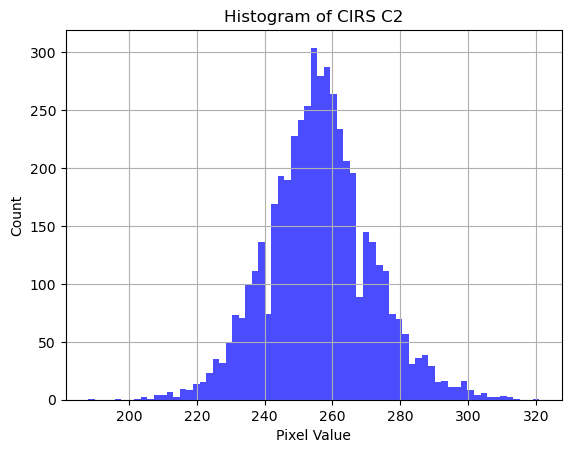

[  1   0   0   0   1   0   0   1   2   1   4   4   7   2   9   8  14  15
  23  35  32  49  73  71 100 111 136  74 169 193 190 228 242 254 304 280
 287 264 234 206 196  89 145 136 116 111  74  70  57  31  36  39  29  15
  16  11  11  16   8   4   6   2   2   3   2   1   0   0   1]
[189.      190.92754 192.85507 194.78261 196.71014 198.63768 200.56522
 202.49275 204.42029 206.34782 208.27536 210.2029  212.13043 214.05797
 215.9855  217.91304 219.84058 221.76811 223.69565 225.62318 227.55072
 229.47826 231.40579 233.33333 235.26086 237.1884  239.11594 241.04347
 242.97101 244.89854 246.82608 248.75362 250.68115 252.60869 254.53622
 256.46378 258.3913  260.31885 262.24637 264.17392 266.10144 268.029
 269.9565  271.88406 273.81158 275.73914 277.66666 279.5942  281.52173
 283.44928 285.3768  287.30435 289.23187 291.15942 293.08694 295.0145
 296.94202 298.86957 300.7971  302.72464 304.65216 306.5797  308.50723
 310.43478 312.3623  314.28986 316.21738 318.14493 320.07245 322.     ]


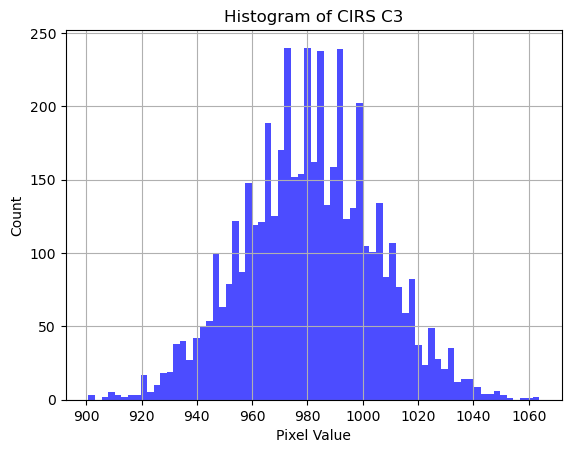

[  3   0   2   5   3   2   3   3  17   5  10  18  19  38  40  27  42  50
  54 100  63  79 122  87 148 119 121 189 125 170 240 152 154 240 162 238
 133 159 239 123 131 202 105 101 134  84 107  77  59  82  37  24  49  28
  21  35  12  14  14   9   4   4   6   3   1   0   1   1   2]
[ 902.       904.3623   906.7246   909.087    911.4493   913.8116
  916.1739   918.53625  920.89856  923.26086  925.62317  927.98553
  930.34784  932.71014  935.07245  937.43475  939.7971   942.1594
  944.5217   946.88403  949.2464   951.6087   953.971    956.3333
  958.6957   961.058    963.4203   965.7826   968.1449   970.50726
  972.86957  975.2319   977.5942   979.95654  982.31885  984.68115
  987.04346  989.4058   991.7681   994.13043  996.49274  998.8551
 1001.2174  1003.5797  1005.942   1008.3043  1010.6667  1013.029
 1015.3913  1017.7536  1020.11597 1022.4783  1024.8406  1027.2029
 1029.5652  1031.9275  1034.2898  1036.6522  1039.0145  1041.3768
 1043.7391  1046.1014  1048.4637  1050.826   1053.1884  1

In [ ]:
if __name__ == "__main__":
    volume = carica_volume_dicom("../Cone-Beam CT/Image_quality/Protocolli CBCT 31_05_2025/Addome-1/6 gradi al secondo/iCBCT-3/FISICA")
    mostra_fette(volume, num_fette=5)


    #Centri CIRS

    centro_C1 = [30, 321, 257]  # esempio: z=50, y=100, x=100
    centro_C2 = [30, 208, 210]  # esempio: z=50, y=100, x=100
    centro_C3 = [30, 254, 323]  # esempio: z=50, y=100, x=100
    
    raggio = 12
    spessore = 10
    
    mask_C1 = crea_roi_cilindrica(volume, centro_C1, raggio, spessore)
    mask_C2 = crea_roi_cilindrica(volume, centro_C2, raggio, spessore)
    mask_C3 = crea_roi_cilindrica(volume, centro_C3, raggio, spessore)

    # Visualizza la ROI da sola sulla slice centrale del cilindro
    mostra_solo_roi(volume, mask_C1, z=centro_C1[0])
    mostra_solo_roi(volume, mask_C2, z=centro_C2[0])
    mostra_solo_roi(volume, mask_C3, z=centro_C3[0])

    # Visualizza la ROI sovrapposta alla slice centrale
    mostra_roi_sovrapposta(volume, mask_C1, z=centro_C1[0])
    mostra_roi_sovrapposta(volume, mask_C2, z=centro_C2[0])
    mostra_roi_sovrapposta(volume, mask_C3, z=centro_C3[0])

    mostra_crop_con_maschera(volume, mask_C1, z=centro_C1[0], margin=20)
    mostra_crop_con_maschera(volume, mask_C2, z=centro_C2[0], margin=20)
    mostra_crop_con_maschera(volume, mask_C3, z=centro_C3[0], margin=20)

    mostra_bordo_proiezione_laterale(volume, mask_C1, num_slices=40)
    mostra_bordo_proiezione_laterale(volume, mask_C2, num_slices=40)
    mostra_bordo_proiezione_laterale(volume, mask_C3, num_slices=40)    

    mostra_crop_laterale_con_maschera(volume, mask_C1, margin=10)
    mostra_crop_laterale_con_maschera(volume, mask_C2, margin=10)
    mostra_crop_laterale_con_maschera(volume, mask_C3, margin=10)

    hist_C1, bin_edges_C1 = calcola_histogram(volume, mask_C1, roi_name='CIRS C1')
    print(hist_C1)
    print(bin_edges_C1)
    hist_C2, bin_edges_C2 = calcola_histogram(volume, mask_C2, roi_name='CIRS C2')
    print(hist_C2)
    print(bin_edges_C2)
    hist_C3, bin_edges_C3 = calcola_histogram(volume, mask_C3, roi_name='CIRS C3')
    print(hist_C3)
    print(bin_edges_C3)
    # Calcola e stampa le metriche degli istogrammi
    metrics_C1 = calcola_metriche_istogramma(hist_C1, bin_edges_C1)
    metrics_C2 = calcola_metriche_istogramma(hist_C2, bin_edges_C2)
    metrics_C3 = calcola_metriche_istogramma(hist_C3, bin_edges_C3)
    print(f"Metrics for CIRS C1: Mean={metrics_C1[0]:.2f}, Median={metrics_C1[1]:.2f}, Variance={metrics_C1[2]:.2f}, Std Dev={metrics_C1[3]:.2f}, Skewness={metrics_C1[4]:.2f}, Kurtosis={metrics_C1[5]:.2f}")
    print(f"Metrics for CIRS C2: Mean={metrics_C2[0]:.2f}, Median={metrics_C2[1]:.2f}, Variance={metrics_C2[2]:.2f}, Std Dev={metrics_C2[3]:.2f}, Skewness={metrics_C2[4]:.2f}, Kurtosis={metrics_C2[5]:.2f}")
    print(f"Metrics for CIRS C3: Mean={metrics_C3[0]:.2f}, Median={metrics_C3[1]:.2f}, Variance={metrics_C3[2]:.2f}, Std Dev={metrics_C3[3]:.2f}, Skewness={metrics_C3[4]:.2f}, Kurtosis={metrics_C3[5]:.2f}")  
    